In [1]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import normalized_mutual_info_score as nmi
from scipy.spatial.distance import cdist, pdist, squareform


import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.plotting import plot_embedding
from scLEMBAS import preprocess
from scLEMBAS import latent_separation as ls


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Kang'

Load files:

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', 'Kang_tf_activity.h5ad'))
tf_adata.obs.rename(columns = {'leiden': 'gene_clusters'}, inplace = True)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Filter for TFs retained ni the signaling network:

In [5]:
tf_labels = tf_adata.var.index.unique().tolist()
og_n = len(tf_labels)

included_nodes = sorted(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
tf_labels = [tf for tf in tf_labels if tf in included_nodes]
print('{} of {} TFs are present in the signaling network'.format(len(tf_labels), og_n))
tf_adata = tf_adata[:,tf_labels]


240 of 423 TFs are present in the signaling network


Embedding details:
- For PCA, we do not zero-center as is the default behavior in scanpy because TF activity is already z-scored
- We choose a resolution for Leiden clustering that maximizes the NMI with the condition, emulating the methods from [here](https://doi.org/10.1038/s41467-024-49806-9). We proceed to use this resolution for all downstream analyses.

In [8]:
file_prefix = os.path.join(data_path, 'processed', author + '_TF_activity_pca')

In [9]:
covariate_associations = ['seurat_annotations', 'stim']

# Start

In [38]:
test = tf_adata.copy()

In [43]:
# if I run:

sc.tl.pca(adata, zero_center = False, use_highly_variable = False)


# As compared to:
    
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD


pca_mod = PCA(n_components=50, random_state = seed)
svd_mod = TruncatedSVD(n_components=50, random_state=seed)


X = adata.X


pca_mod.fit(X)
X_pca = pca_mod.transform(X) # need to separate fit_transform otherwise won't be able to reproducibly run .transform

svd_mod.fit(X)
X_pca = svd_mod.transform(X) # need to separate fit_transform otherwise won't be able to reproducibly run .transform



X_pca = svd.fit_transform(X)

adata.obsm["X_pca"] = X_pca
adata.varm["PCs"] = pca_mod.components_.T

# I see that the scanpy PC components 2 and 3 seem to correspond to that of 1 and 2 of PCA (visually in terms of the covariates of interest). What would cause this discrepancy?

In [54]:
adata = tf_adata.copy()

In [57]:

from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD


pca_mod = PCA(n_components=50, random_state = seed)
svd_mod = TruncatedSVD(n_components=50, random_state=seed)


X = adata.X


# pca_mod.fit(X)
# X_pca = pca_mod.transform(X) # need to separate fit_transform otherwise won't be able to reproducibly run .transform

svd_mod.fit(X) # need to separate fit_transform otherwise won't be able to reproducibly run .transform
X_pca = svd_mod.transform(X)

adata.obsm["X_pca"] = X_pca
adata.varm["PCs"] = svd_mod.components_.T

# I see that the scanpy PC components 2 and 3 seem to correspond to that of 1 and 2 of PCA (visually in terms of the covariates of interest). What would cause this discrepancy?

In [48]:
adata = tf_adata.copy()

In [50]:
from sklearn.decomposition import PCA

pca_mod = PCA(n_components=50, random_state = seed)
X = adata.X
pca_mod.fit(X)
X_pca = pca_mod.transform(X) # need to separate fit_transform otherwise won't be able to reproducibly run .transform
adata.obsm["X_pca"] = X_pca
adata.varm["PCs"] = pca_mod.components_.T

uns_entry = {
    "params": {
        "zero_center": True,
        "use_highly_variable": False,
        "mask": None,
    },
    "variance": pca_mod.explained_variance_,
    "variance_ratio": pca_mod.explained_variance_ratio_,
    "pca_mod": pca_mod
}
adata.uns["pca"] = uns_entry

In [58]:
variance_ratio = adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(variance_ratio))) + 1
kneedle = KneeLocator(x = pcs, y = variance_ratio, curve='convex', direction='decreasing')
rank = kneedle.elbow

In [61]:
cumulative_variance_ratio = np.cumsum(adata.uns['pca']['variance_ratio']) #adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(cumulative_variance_ratio))) + 1
kneedle = KneeLocator(x = pcs, y = cumulative_variance_ratio, curve='concave', direction='increasing')
rank = kneedle.elbow
rank

13

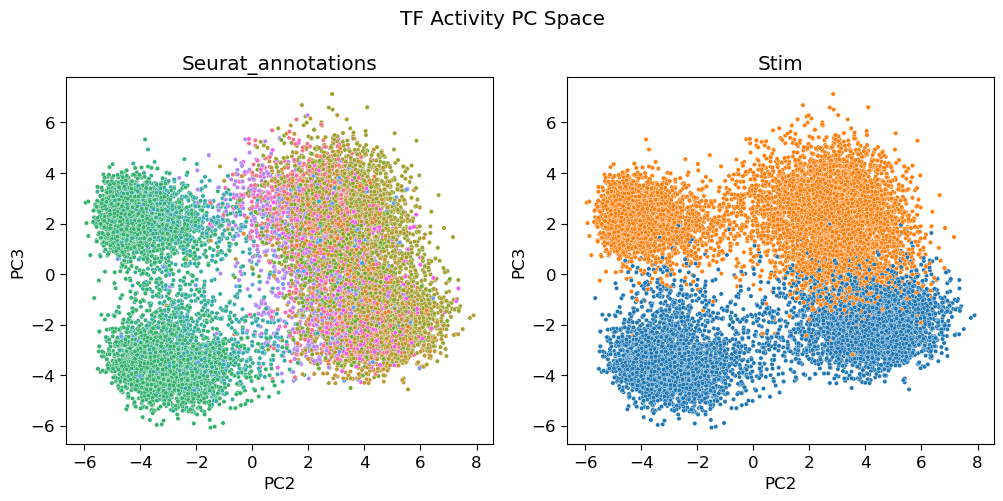

In [62]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pca', 
    covariates = ['seurat_annotations', 'stim'],
    components = [2,3], 
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = None,
)

In [63]:
# Compare the two approaches
from sklearn.decomposition import TruncatedSVD, PCA

# Scanpy's approach (zero_center=False)
svd = TruncatedSVD(n_components=50, random_state=seed)
X_svd = svd.fit_transform(adata.X)

# Your sklearn PCA approach  
pca = PCA(n_components=50, random_state=seed)
X_pca = pca.fit_transform(adata.X)

# Check if PC1 from SVD captures the mean
print("SVD PC1 correlation with mean expression:", 
      np.corrcoef(X_svd[:, 0], adata.X.mean(axis=1))[0, 1])

# Compare components
print("\nCorrelation between SVD PC2 and PCA PC1:", 
      np.corrcoef(X_svd[:, 1], X_pca[:, 0])[0, 1])
print("Correlation between SVD PC3 and PCA PC2:", 
      np.corrcoef(X_svd[:, 2], X_pca[:, 1])[0, 1])

SVD PC1 correlation with mean expression: 0.8338643729936388

Correlation between SVD PC2 and PCA PC1: 0.993955579535111
Correlation between SVD PC3 and PCA PC2: 0.9982777903073828


Mean TF activity: 0.1293
Median TF activity: 0.0940
Proportion of positive scores: 0.5606


# End

In [10]:
tf_adata.obs['condition'] = tf_adata.obs.stim.astype(str) + '^' + tf_adata.obs.seurat_annotations.astype(str)

# ls.embed_adata(
#     adata = tf_adata,
#     seed = 888,
    
#     # pca
#     n_components = 50, 
#     pc_rank = 'automate',
#     scale = False, # TF activity is z-scored
#     pcakwrgs = {
#         'zero_center': False, # TF activity is z-scored
#         'use_highly_variable': False, # there are no HVGs so this is by default the behavior
#                }, 
    
#     # umap
#     run_umap = True, 
    
#     # clustering
#     cluster_data = True,
#     n_neighbors = 15,
#     resolution = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
#     cluster_col_name = 'TF_clusters',
#     nmi_label = 'condition', 
    
# )


tf_adata, r2_df = ls.pc_pipeline(
    adata = tf_adata,
    pert_ids = tf_adata.obs.stim.unique(), # don't subset
    cat_ids = tf_adata.obs.seurat_annotations.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'stim',
    cat_col = 'seurat_annotations',
    get_hvgs = False, # tf activity doesn't use HVGs 
    run_umap = True,
    covariate_associations = covariate_associations, 
    file_prefix = file_prefix,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': True, 
        'n_neighbors': 15,
        'resolution': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
        'cluster_col_name': 'TF_clusters',
        'nmi_label': 'condition', 
        
        'scale': False, # TF activity is z-scored
        'pcakwrgs': {
            'use_highly_variable': False, # TF activity is z-scored
            'zero_center': False # there are no HVGs so this is by default the behavior
        }    
    }
)

tf_adata.obs.drop(columns = ['condition'], inplace = True)

Iterate through leiden resolutions


100%|█████████████████████████████████████████████| 6/6 [00:09<00:00,  1.65s/it]


seurat_annotations


100%|██████████████████████████████████████████| 13/13 [00:00<00:00, 201.11it/s]


stim


100%|██████████████████████████████████████████| 13/13 [00:00<00:00, 653.28it/s]


seurat_annotations


100%|███████████████████████████████████████████| 13/13 [00:03<00:00,  3.77it/s]


stim


100%|███████████████████████████████████████████| 13/13 [00:02<00:00,  4.61it/s]


The elbow was automatically identified at PC 13


''

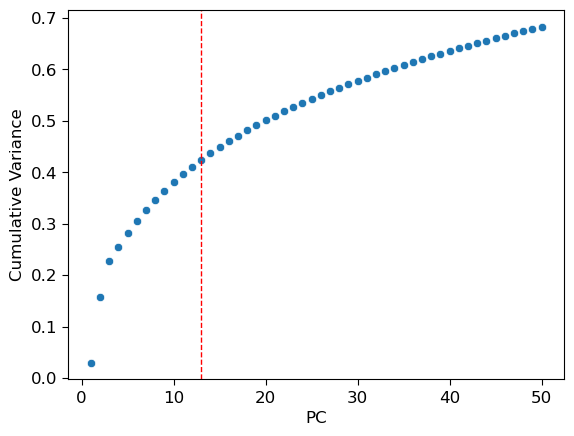

In [11]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(tf_adata.uns['pca']['variance_ratio']),
    x=range(1, tf_adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = tf_adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

The two PC components that best univariately separate by seurat_annotations are components 2 and 1 explaining 86.65% and 67.20% of variance, respectively
The two PC components that best univariately separate by stim are components 3 and 1 explaining 76.48% and 8.92% of variance, respectively


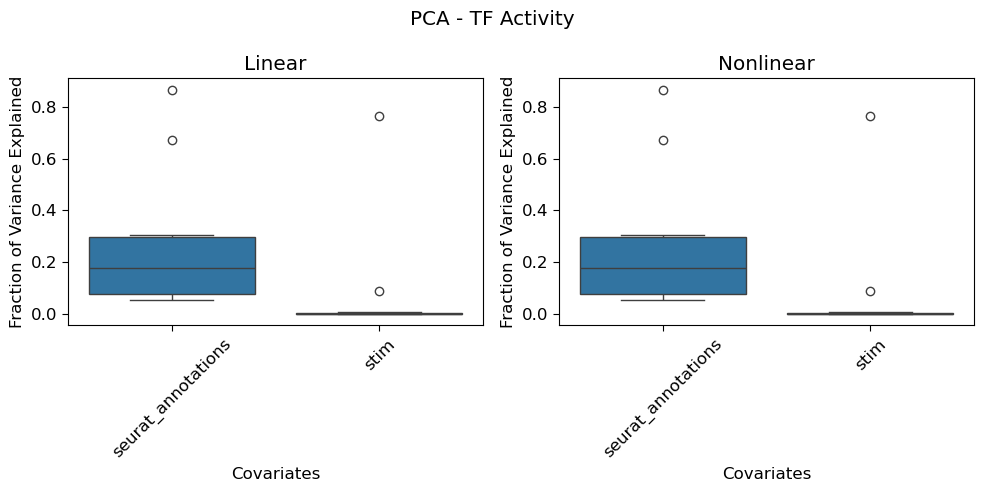

In [22]:
ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PCA - TF Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_cell = ls.get_top_components(r2_df, top_components_cov = 'seurat_annotations')
top_components_pert = ls.get_top_components(r2_df, top_components_cov = 'stim')


In [32]:
cat_cov = ['gene_clusters', 'TF_clusters', 'seurat_annotations', 'stim']
NMI_df = pd.DataFrame(columns = ['NMI'], 
                      index = ['^'.join(comb) for comb in itertools.combinations(cat_cov, 2)])
for comb in NMI_df.index:
    NMI_df.loc[comb, 'NMI'] = nmi(tf_adata.obs[comb.split('^')[0]], tf_adata.obs[comb.split('^')[1]])
    
NMI_df

,NMI
gene_clusters^TF_clusters,0.506166
gene_clusters^seurat_annotations,0.450357
gene_clusters^stim,0.284544
TF_clusters^seurat_annotations,0.463678
TF_clusters^stim,0.31754
seurat_annotations^stim,0.003175


We will use components 2 and 3 for visualization of PC space, accordingly.

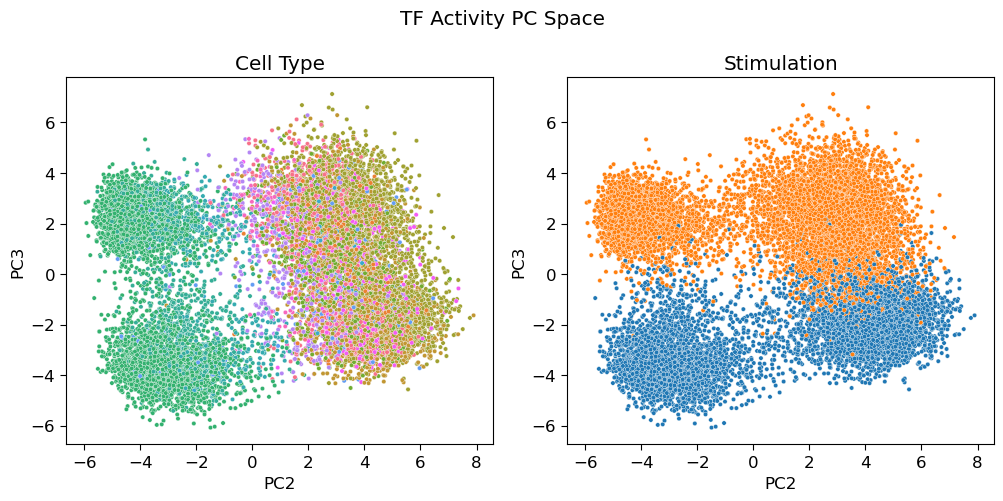

In [33]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'pca', 
    covariates = ['seurat_annotations', 'stim'],
    panel_titles = ['Cell Type', 'Stimulation'],
    components = [2, 3], 
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

## PCA side-note

Note on PC1. PC1 is capturing mean TF activity. While we chose not to zero-center due to these being 'consensus' scores, there is still a bias in the activity distribution: 

In [66]:
print(f"Mean TF activity: {tf_adata.X.mean():.4f}")
print(f"Median TF activity: {np.median(tf_adata.X):.4f}")
print(f"Proportion of positive scores: {(tf_adata.X > 0).mean():.4f}")

Mean TF activity: 0.1293
Median TF activity: 0.0940
Proportion of positive scores: 0.5606


These statistics show that decoupler's consensus TF activities have a systematic positive shift - the mean is positive (0.13), median is positive (0.09), and 56% of values are positive. Thus, **PC1 is going to capture this shift (in other words, the mean)** (which could be due to e.g., net positive TF activity or some sort of background shift). 

Biologically, PC1 likely represents one or more of the following::
- Global transcriptional activity state - cells with generally higher TF activity across the board
- Technical variation - cells with better capture/sequencing might show higher activities
- Cell state - metabolically active vs. quiescent cells


Let's see the correlation between PC1 and the mean:

In [73]:
import scipy
pr = scipy.stats.pearsonr(tf_adata.obsm['X_pca'][:, 0], tf_adata.X.mean(axis=1)).statistic
print('Pearson correlation between PC1 and data mean: {:.2f}'.format(pr))

Pearson correlation between PC1 and data mean: 0.83


Furthermore, we can see that with zero-centering, PC1 is removed, and instead PC2 and PC3 become PC1 and PC2:

In [77]:
ta_zc = tf_adata.copy()
sc.tl.pca(ta_zc, zero_center = True)

pr = scipy.stats.pearsonr(ta_zc.obsm['X_pca'][:, 0], tf_adata.obsm['X_pca'][:, 1]).statistic
print('Pearson correlation between zero-centered PC1 and non-zero-centered PC2: {:.2f}'.format(pr))
pr = scipy.stats.pearsonr(ta_zc.obsm['X_pca'][:, 1], tf_adata.obsm['X_pca'][:, 2]).statistic
print('Pearson correlation between zero-centered PC2 and non-zero-centered PC3: {:.2f}'.format(pr))

Pearson correlation between zero-centered PC1 and non-zero-centered PC2: 0.99
Pearson correlation between zero-centered PC2 and non-zero-centered PC3: 1.00


Because 1) this information is retained in the decomposition, 2) conesnsus scores are input to the PCA, and 3) PC1 without zero-centering still represents some information (either global TF activity state or technical covariance), we proceed without zero-centering

In [89]:
# stats_adata = tf_adata.copy()
# stats_adata.uns['pca']['pca_rank'] = 3

# r2_df = ls.latent_association(
#     adata = stats_adata, 
#     covariates = ['nCount_RNA', 'seurat_annotations', 'stim'], 
#     model_type = 'linear', 
#     n_cores = n_cores, 
#     latent_label = 'pca', 
#     seed = 888
# )

# r2_df.drop('model_type', axis=1).pivot_table(
#     columns='PC', 
#     values=['nCount_RNA', 'seurat_annotations', 'stim']
# )

## End Side-Note

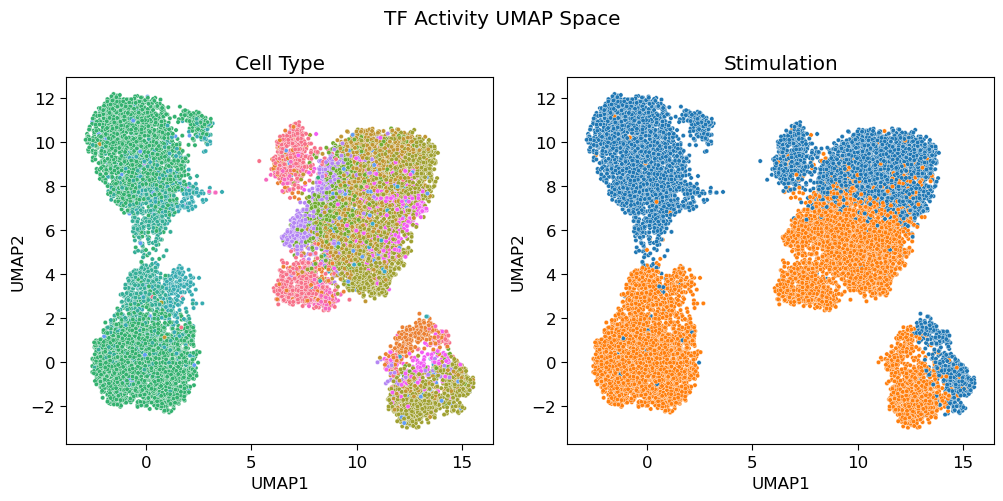

In [34]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'umap', 
    covariates = ['seurat_annotations', 'stim'],
    panel_titles = ['Cell Type', 'Stimulation'],
    components = [1,2], 
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

In [35]:
io.write_tfad(tf_adata, os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))